# TMDB Film Gişe Rekortmeni Projesi

**Hazırlayan:** Barış Yıldırım

Bu projede, TMDB (The Movie Database) 5000 film veri seti kullanılarak bir filmin hasılat performansının tahmin edilmesi amaçlanmıştır. Veri seti üzerinde keşifsel veri analizi (EDA), özellik mühendisliği (Feature Engineering) ve çeşitli Gradient Boosting tabanlı makine öğrenmesi algoritmaları uygulanmıştır.

## 1. Kütüphaneler ve Veri Yükleme

Projede kullanılan temel kütüphaneler: **pandas** (veri manipülasyonu), **numpy** (sayısal hesaplamalar), **matplotlib/seaborn** (görselleştirme), **scikit-learn** (model değerlendirme ve ön işleme), **XGBoost**, **CatBoost** ve **LightGBM** (Gradient Boosting modelleri).

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from catboost import CatBoostClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

In [72]:
df = pd.read_csv("tmdb_5000_movies.csv")
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [73]:
df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


## 2. Keşifsel Veri Analizi (EDA - Exploratory Data Analysis)

EDA, veri bilimi projelerinin en kritik adımlarından biridir. Bu bölümde:
- Veri setinin genel yapısı ve boyutu incelenir
- Değişken tipleri ve eksik veriler tespit edilir
- Temel istatistiksel özetler çıkarılır
- Değişkenlerin dağılımları görselleştirilir

In [74]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

### 2.1. Tanımlayıcı İstatistikler (Descriptive Statistics)

Veri setindeki sayısal değişkenlerin merkezi eğilim (ortalama, medyan), yayılım (standart sapma, min, max) ve çeyreklik değerlerini inceliyoruz. Histogramlar ile dağılım şekillerini, boxplot'lar ile aykırı değerleri görselleştiriyoruz.

TANIMLAYICI İSTATİSTİKLER


,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


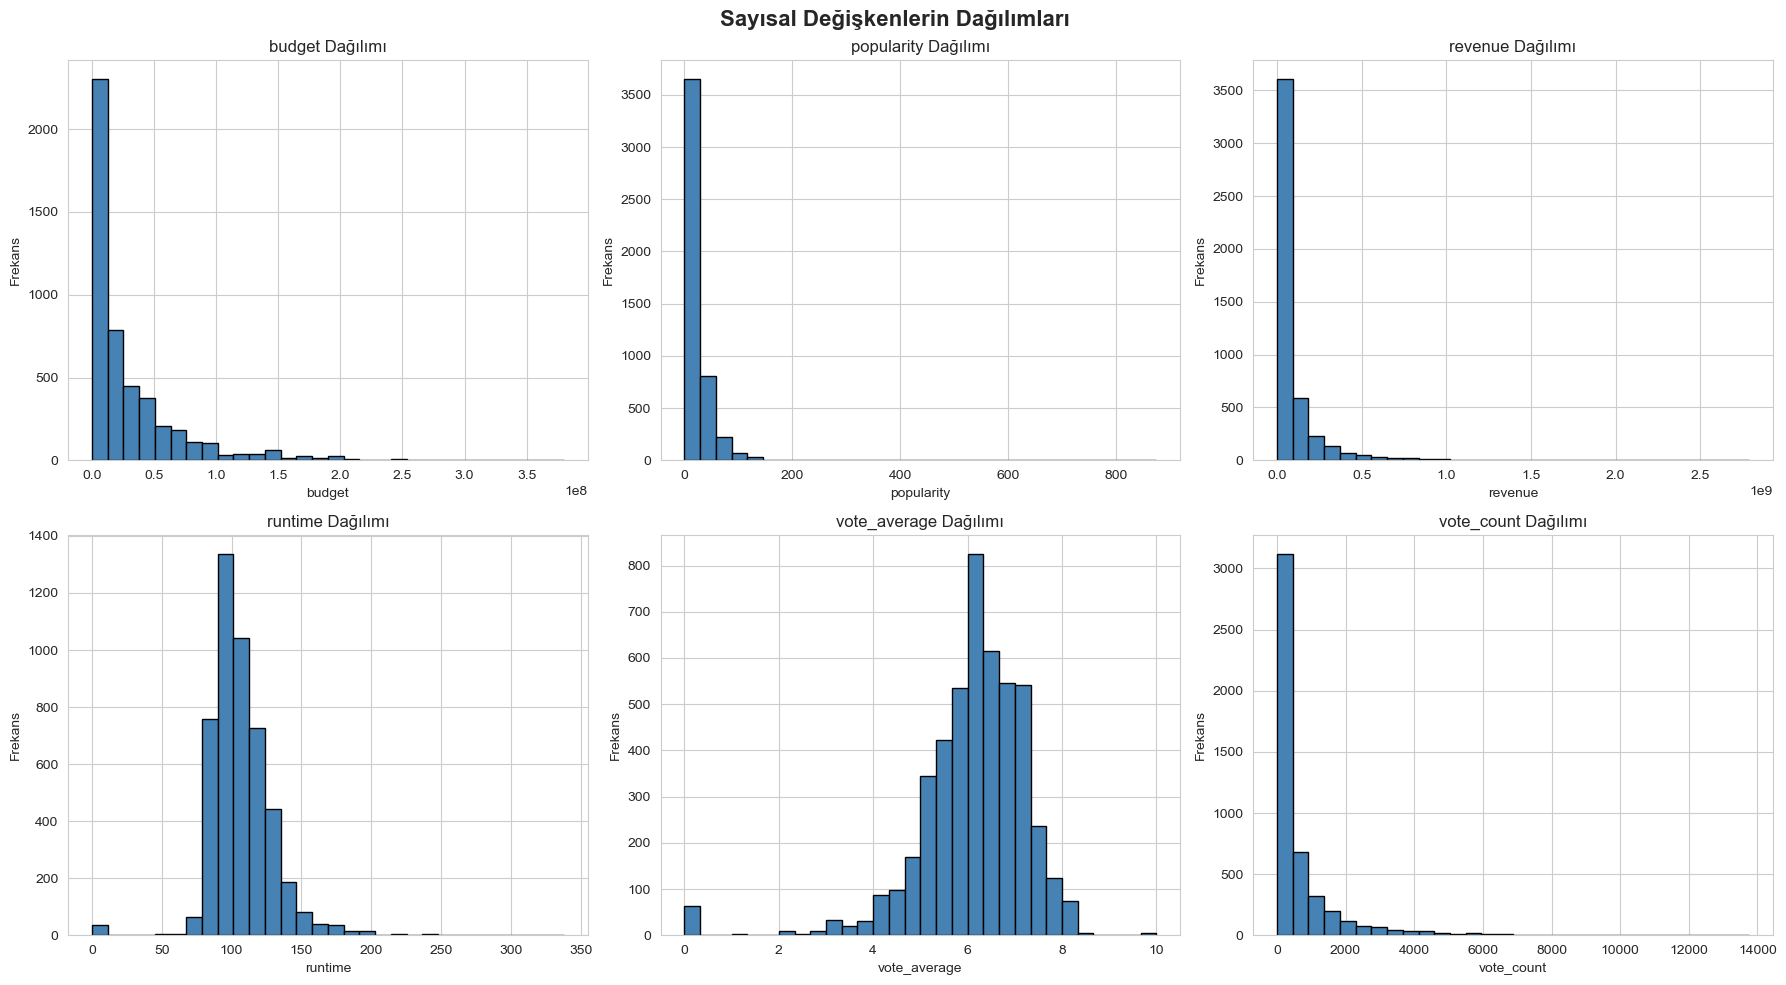

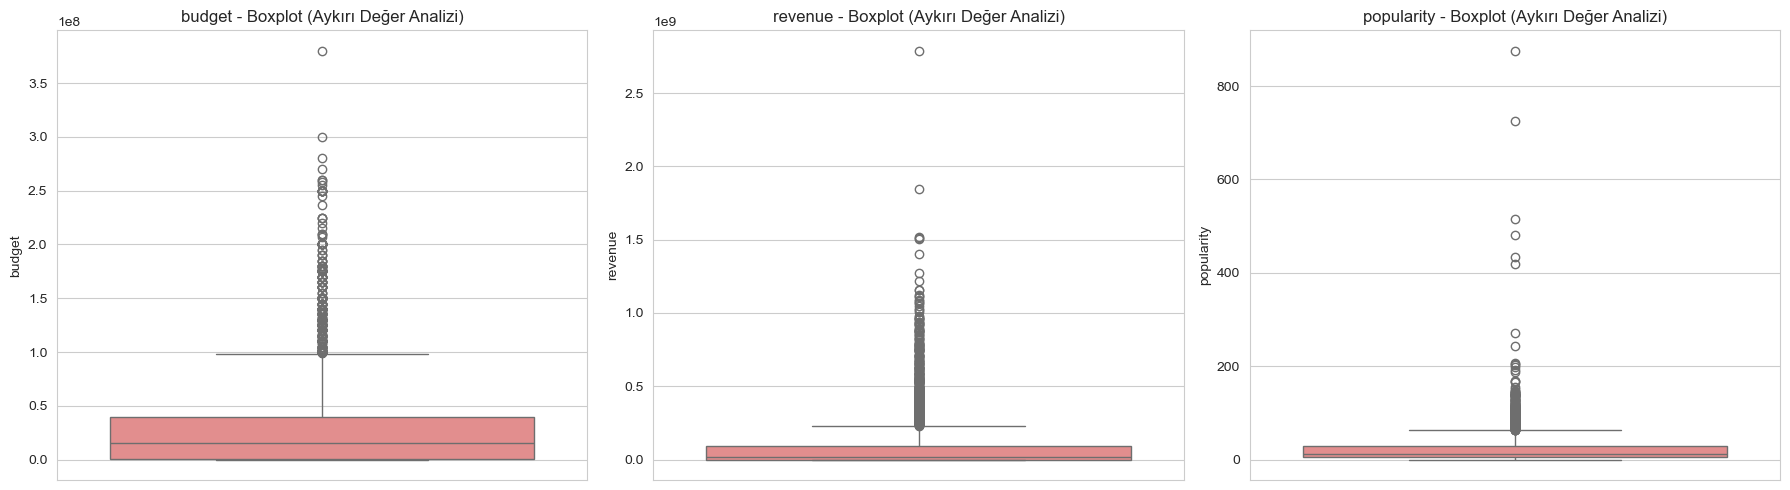

In [75]:
# --- Tanımlayıcı İstatistikler ---
print('='*60)
print('TANIMLAYICI İSTATİSTİKLER')
print('='*60)
display(df.describe())

# Sayısal değişkenlerin dağılımı
numeric_cols = ['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx2, col in enumerate(numeric_cols):
    row, c = divmod(idx2, 3)
    df[col].dropna().hist(bins=30, ax=axes[row][c], color='steelblue', edgecolor='black')
    axes[row][c].set_title(f'{col} Dağılımı')
    axes[row][c].set_xlabel(col)
    axes[row][c].set_ylabel('Frekans')
plt.suptitle('Sayısal Değişkenlerin Dağılımları', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Boxplot ile aykırı değer analizi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx2, col in enumerate(['budget', 'revenue', 'popularity']):
    sns.boxplot(y=df[col], ax=axes[idx2], color='lightcoral')
    axes[idx2].set_title(f'{col} - Boxplot (Aykırı Değer Analizi)')
plt.tight_layout()
plt.show()

### 2.2. Eksik Veri Analizi ve Veri Temizleme

Eksik değerlerin tespiti ve veri setinden budget=0, revenue=0 ve genres boş olan kayıtların temizlenmesi.

In [76]:
df.isnull().sum()

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

In [77]:
df[df["release_date"].isnull()]

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
4553,0,[],NaN,380097,[],en,America Is Still the Place,1971 post civil rights San Francisco seemed li...,0.0,[],[],NaN,0,0.0,[],Released,NaN,America Is Still the Place,0.0,0


In [78]:
print((df['genres'] == '[]').sum())
df = df[df['genres'] != '[]']
print((df['genres'] == '[]').sum())

28
0


In [79]:
print((df["budget"] == 0).sum())
df = df.loc[df.budget != 0]
print((df["budget"] == 0).sum())

1013
0


In [80]:
print((df["revenue"] == 0).sum())
df = df.loc[df.revenue != 0]
print((df["revenue"] == 0).sum())

534
0


In [81]:
df.loc[df.popularity == 0]

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count


## 3. Feature Engineering (Özellik Mühendisliği)

Feature Engineering, ham veriden model performansını artıracak yeni özellikler türetme sürecidir. Bu projede yapılan işlemler:

- **Tarih özelliği çıkarma:** `release_date` kolonundan yayın ayı (`release_month`) çıkarıldı. Filmlerin hangi ayda vizyona girdiği hasılat üzerinde etkili olabilir.
- **Tür (Genre) kodlaması:** JSON formatındaki tür verileri parse edildi. Düşük hasılatlı türler 'Others' olarak gruplandırıldı ve Multi-Label Binarizer ile one-hot encoding uygulandı.
- **Özellik seçimi:** Modele sadece anlamlı sayısal ve kategorik özellikler dahil edildi (budget, popularity, release_month, vote_average, vote_count ve tür kodlamaları).
- **Hedef değişken oluşturma:** Revenue medyanı eşik değer olarak alınarak ikili sınıflandırma problemi oluşturuldu (0: Düşük Hasılat, 1: Rekortmen).
- **Ölçeklendirme:** StandardScaler ile sayısal özellikler standardize edildi.

In [82]:
df["release_date"].unique()
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

df['release_month'] = df['release_date'].dt.month
df['release_month'].unique()

array([12,  5, 10,  7,  3, 11,  4,  6,  2,  8,  9,  1], dtype=int32)

In [83]:
reduced_df = df[["budget","popularity","release_month","genres","revenue","vote_average","vote_count"]].copy().reset_index(drop=True)
reduced_df.head()

,budget,popularity,release_month,genres,revenue,vote_average,vote_count
0,237000000,150.437577,12,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",2787965087,7.2,11800
1,300000000,139.082615,5,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",961000000,6.9,4500
2,245000000,107.376788,10,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",880674609,6.3,4466
3,250000000,112.312950,7,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",1084939099,7.6,9106
4,260000000,43.926995,3,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",284139100,6.1,2124


In [84]:
reduced_df.shape

(3228, 7)

In [85]:
reduced_df['genres_list'] = reduced_df['genres'].apply(lambda x: [i['name'] for i in ast.literal_eval(x)] if pd.notnull(x) else [])
genre_stats = reduced_df.explode('genres_list').groupby('genres_list')['revenue'].median()
low_revenue_genres = set(genre_stats.nsmallest(8).index)

def process_genres(genre_list):
    new_list = [g for g in genre_list if g not in low_revenue_genres]
    if any(g in low_revenue_genres for g in genre_list):
        new_list.append('Others')
    return list(set(new_list))

reduced_df['final_genres'] = reduced_df['genres_list'].apply(process_genres)

mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(reduced_df['final_genres']), 
    columns=mlb.classes_, 
    index=reduced_df.index
)

reduced_df = reduced_df.drop(['genres', 'genres_list'], axis=1, errors='ignore')

regulated_df = pd.concat([reduced_df, genre_encoded], axis=1)

### 3.1. Veri Görselleştirme

Özellik mühendisliği sonrası değişkenler arasındaki ilişkileri regresyon grafikleri ile inceliyoruz.

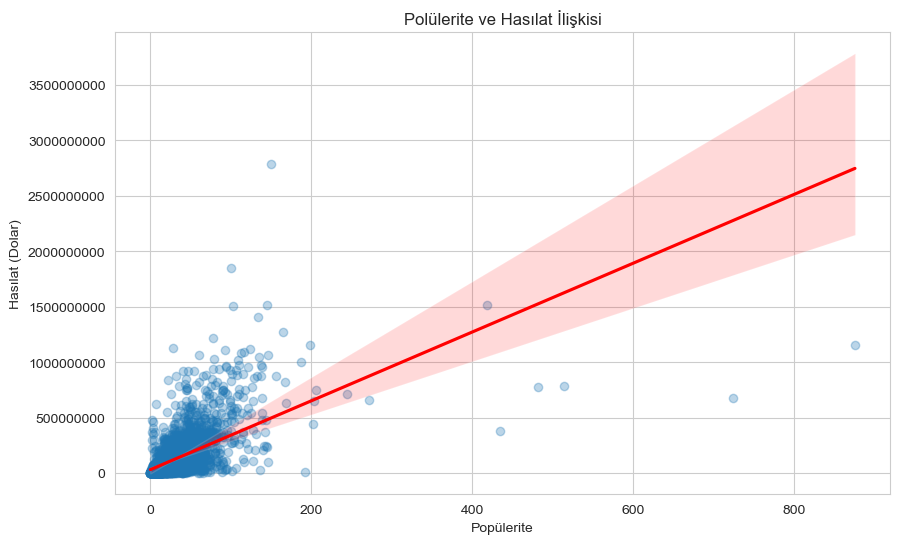

In [86]:
plt.figure(figsize=(10, 6))
sns.regplot(x='popularity', y='revenue', data=regulated_df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Polülerite ve Hasılat İlişkisi')
plt.xlabel('Popülerite')
plt.ylabel('Hasılat (Dolar)')
plt.ticklabel_format(style='plain', axis='both') 
plt.show()

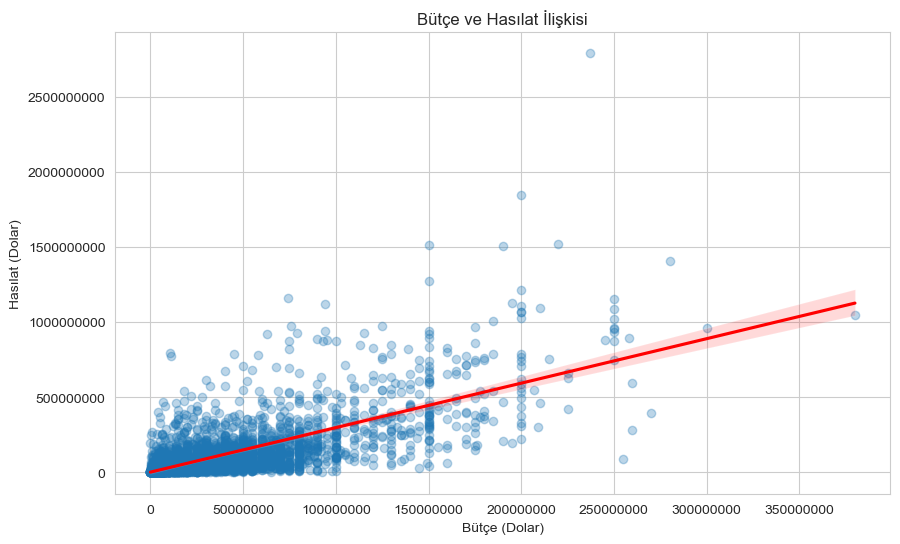

In [87]:
plt.figure(figsize=(10, 6))
sns.regplot(x='budget', y='revenue', data=regulated_df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Bütçe ve Hasılat İlişkisi')
plt.xlabel('Bütçe (Dolar)')
plt.ylabel('Hasılat (Dolar)')
plt.ticklabel_format(style='plain', axis='both') 
plt.show()

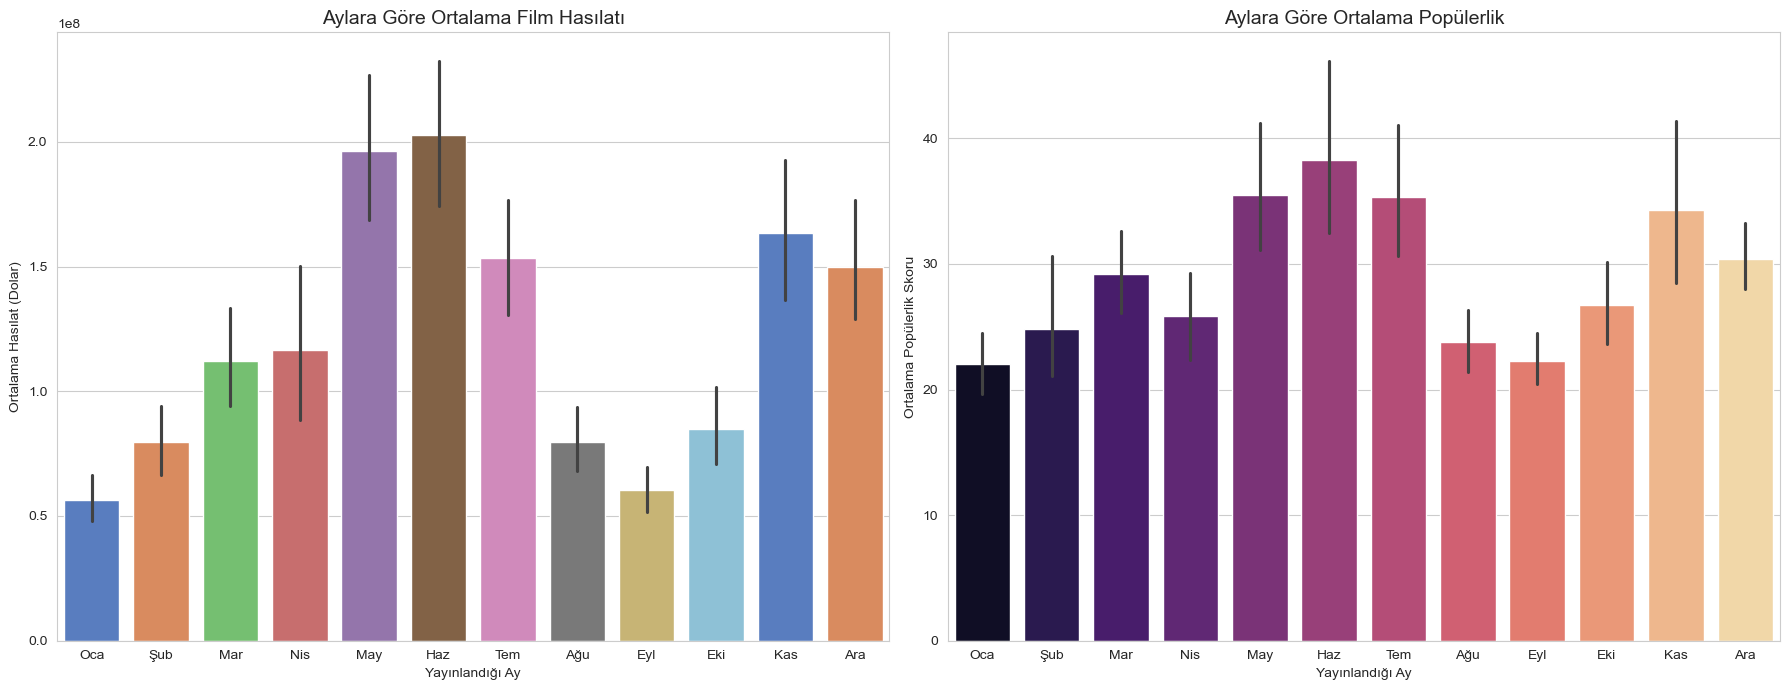

In [88]:
month = ['Oca', 'Şub', 'Mar', 'Nis', 'May', 'Haz', 'Tem', 'Ağu', 'Eyl', 'Eki', 'Kas', 'Ara']
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(ax=axes[0], x='release_month', y='revenue', data=regulated_df, palette='muted')
axes[0].set_title('Aylara Göre Ortalama Film Hasılatı', fontsize=14)
axes[0].set_xlabel('Yayınlandığı Ay')
axes[0].set_ylabel('Ortalama Hasılat (Dolar)')
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(month)

sns.barplot(ax=axes[1], x='release_month', y='popularity', data=regulated_df, palette='magma')
axes[1].set_title('Aylara Göre Ortalama Popülerlik', fontsize=14)
axes[1].set_xlabel('Yayınlandığı Ay')
axes[1].set_ylabel('Ortalama Popülerlik Skoru')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(month)

plt.tight_layout()
plt.show()

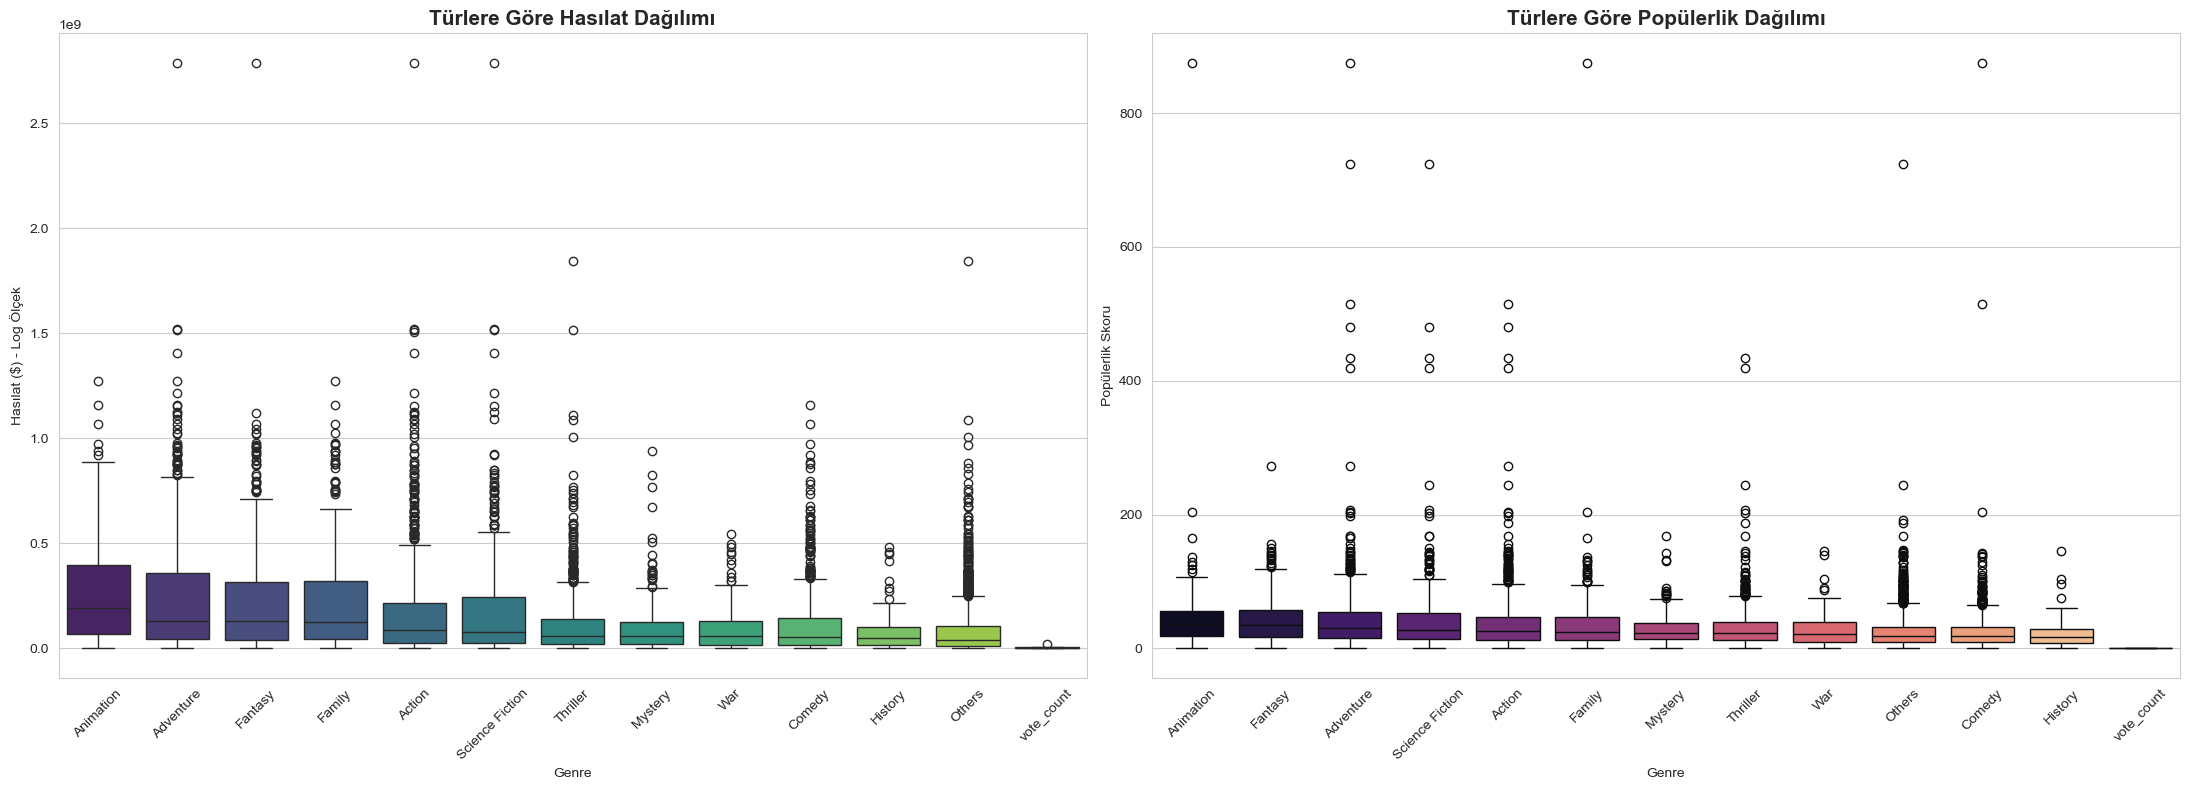

In [89]:
exclude = ['revenue', 'budget', 'id', 'popularity', 'release_month']
genre_cols = [col for col in regulated_df.columns if col not in exclude]

df_rev_plot = regulated_df.melt(id_vars=['revenue'], value_vars=genre_cols, var_name='Genre', value_name='Exists')
df_rev_plot = df_rev_plot[df_rev_plot['Exists'] == 1]

df_pop_plot = regulated_df.melt(id_vars=['popularity'], value_vars=genre_cols, var_name='Genre', value_name='Exists')
df_pop_plot = df_pop_plot[df_pop_plot['Exists'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
sns.set_style("whitegrid")

order_rev = df_rev_plot.groupby('Genre')['revenue'].median().sort_values(ascending=False).index
sns.boxplot(ax=axes[0], x='Genre', y='revenue', data=df_rev_plot, order=order_rev, palette='viridis')
axes[0].set_title('Türlere Göre Hasılat Dağılımı', fontsize=15, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Hasılat ($) - Log Ölçek')

order_pop = df_pop_plot.groupby('Genre')['popularity'].median().sort_values(ascending=False).index
sns.boxplot(ax=axes[1], x='Genre', y='popularity', data=df_pop_plot, order=order_pop, palette='magma')
axes[1].set_title('Türlere Göre Popülerlik Dağılımı', fontsize=15, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Popülerlik Skoru')

plt.tight_layout()
plt.show()

In [90]:
threshold = regulated_df['revenue'].quantile(0.75)
print(f"Başarı Eşiği: ${threshold:,.0f}")
regulated_df['is_blockbuster'] = (regulated_df['revenue'] >= threshold).astype(int)

Başarı Eşiği: $146,343,450


In [91]:
regulated_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3228 entries, 0 to 3227
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   budget           3228 non-null   int64  
 1   popularity       3228 non-null   float64
 2   release_month    3228 non-null   int32  
 3   revenue          3228 non-null   int64  
 4   vote_average     3228 non-null   float64
 5   vote_count       3228 non-null   int64  
 6   final_genres     3228 non-null   object 
 7   Action           3228 non-null   int64  
 8   Adventure        3228 non-null   int64  
 9   Animation        3228 non-null   int64  
 10  Comedy           3228 non-null   int64  
 11  Family           3228 non-null   int64  
 12  Fantasy          3228 non-null   int64  
 13  History          3228 non-null   int64  
 14  Mystery          3228 non-null   int64  
 15  Others           3228 non-null   int64  
 16  Science Fiction  3228 non-null   int64  
 17  Thriller      

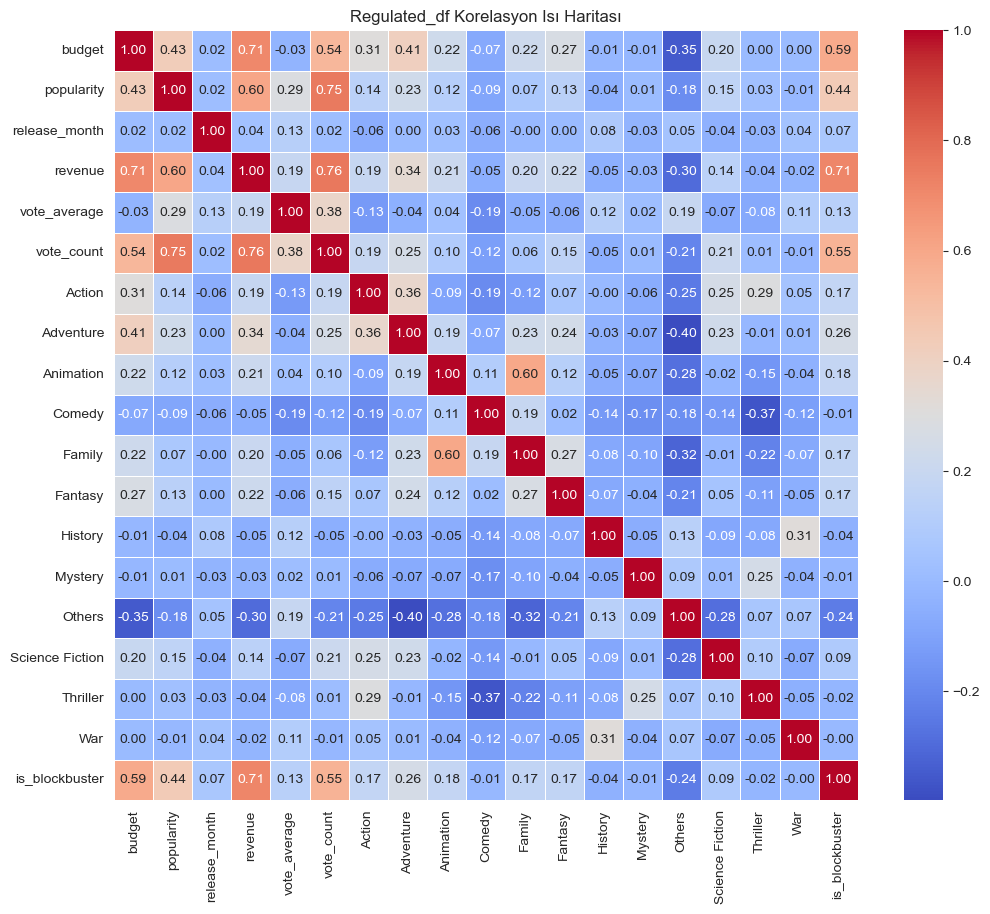

In [92]:
plt.figure(figsize=(12, 10)) 
sns.heatmap(regulated_df.corr(numeric_only=True), 
            annot=True,      
            cmap='coolwarm', 
            fmt=".2f",       
            linewidths=0.5)  

plt.title('Regulated_df Korelasyon Isı Haritası')
plt.show()

In [93]:
features = ["budget","popularity","release_month","vote_average","vote_count"]+list(mlb.classes_)
X = regulated_df[features]
y = regulated_df["is_blockbuster"]

In [94]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.111, random_state=42, stratify=y_train_val
)

In [95]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## 4. Kullanılan Algoritmalar ve Seçim Nedenleri

Bu projede **Gradient Boosting** ailesi algoritmalar tercih edilmiştir. Bu tercihin nedenleri:

| Özellik | Açıklama |
|---------|---------|
| **Tabular verilerdeki başarı** | Gradient Boosting modelleri, tablo (tabular) verilerde neredeyse her zaman en yüksek performansı gösterir. Kaggle yarışmalarının büyük çoğunluğu bu algoritmalarla kazanılmıştır. |
| **Aykırı değerlere direnç** | Ağaç tabanlı modeller, aykırı değerlerden lineer modellere göre çok daha az etkilenir. |
| **Otomatik özellik etkileşimi** | Karar ağaçları, özellikler arasındaki karmaşık etkileşimleri otomatik olarak yakalar. |
| **Eksik veriye tolerans** | XGBoost ve LightGBM, eksik verileri doğal olarak handle edebilir. |
| **Hiperparametre optimizasyonu** | RandomizedSearchCV ile hiperparametre araması yapılarak en iyi model konfigürasyonu bulunmuştur. |

**Kullanılan modeller:**
- **XGBoost:** En yaygın gradient boosting implementasyonu. L1/L2 regularizasyon desteği.
- **CatBoost:** Kategorik özelliklerle doğrudan çalışabilir. Ordered boosting ile overfitting'i azaltır.
- **LightGBM:** Leaf-wise büyüme stratejisi ile daha hızlı eğitim. Büyük veri setlerinde avantajlı.

### 4.1. XGBoost (Extreme Gradient Boosting)

XGBoost, gradient boosting framework'ünün optimize edilmiş bir implementasyonudur. `RandomizedSearchCV` ile 5-fold cross-validation kullanılarak en iyi hiperparametreler aranmıştır. Scoring metriği olarak **F1 skoru** tercih edilmiştir çünkü dengesiz sınıf dağılımlarında accuracy yanıltıcı olabilir.

In [96]:
param_dist_xgb = {
    'n_estimators': [100, 300, 500, 1000], 
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],             
    'subsample': [0.7, 0.8, 0.9],          
    'colsample_bytree': [0.6, 0.8, 1.0],   
    'gamma': [ 0,0.1,0.3]                 
}
clf_xgb = XGBClassifier(
    verbosity=0,
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='logloss',
    scale_pos_weight=1.2,
    early_stopping_rounds=10
)
clf_search_xgb = RandomizedSearchCV(
    clf_xgb,
    param_distributions=param_dist_xgb,
    n_iter=15,         
    cv=5,                
    scoring='f1',       
    n_jobs=-1
)
clf_search_xgb.fit(X_train, y_train,eval_set=[(X_val, y_val)],
    verbose=False)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,15
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [97]:
best_model = clf_search_xgb.best_estimator_
y_pred = best_model.predict(X_test)
print("\n--- Rekortmen Tahmin Raporu ---")
print(classification_report(y_test, y_pred))
print(f"Model Doğruluğu: %{accuracy_score(y_test, y_pred)*100:.2f}")


--- Rekortmen Tahmin Raporu ---
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       242
           1       0.81      0.73      0.77        81

    accuracy                           0.89       323
   macro avg       0.86      0.84      0.85       323
weighted avg       0.89      0.89      0.89       323

Model Doğruluğu: %88.85


### 4.2. CatBoost

CatBoost, Yandex tarafından geliştirilen gradient boosting algoritmasıdır. Kategorik değişkenlerle doğrudan çalışabilmesi ve ordered boosting tekniği ile overfitting riskini azaltması en önemli avantajlarıdır.

In [98]:
param_dist = {
    'iterations': [300,500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [ 3, 5, 9],
    'scale_pos_weight': [1.2, 1.5, 2.0], 
    'random_strength': [0, 1, 2]         
}
from catboost import CatBoostClassifier
model_cat = CatBoostClassifier(logging_level='Silent', random_seed=42)
clf_search = RandomizedSearchCV(
    estimator=model_cat,
    param_distributions=param_dist,
    n_iter=15,           
    cv=5,                
    scoring='f1',        
    n_jobs=-1,
    random_state=42
)
clf_search.fit(X_train, y_train,early_stopping_rounds=10, 
           eval_set=[(X_val, y_val)],
           verbose=False)

,estimator,CatBoostClass...andom_seed=42)
,param_distributions,"{'depth': [4, 6, ...], 'iterations': [300, 500, ...], 'l2_leaf_reg': [3, 5, ...], 'learning_rate': [0.01, 0.05, ...], ...}"
,n_iter,15
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [99]:
best_cat = clf_search.best_estimator_
y_pred = best_cat.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"Genel Doğruluk: %{accuracy_score(y_test, y_pred)*100:.2f}")

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       242
           1       0.80      0.75      0.78        81

    accuracy                           0.89       323
   macro avg       0.86      0.85      0.85       323
weighted avg       0.89      0.89      0.89       323

Genel Doğruluk: %89.16


### 4.3. LightGBM (Light Gradient Boosting Machine)

LightGBM, Microsoft tarafından geliştirilen hızlı ve yüksek performanslı bir gradient boosting framework'üdür. **Leaf-wise** (yaprak bazlı) büyüme stratejisi kullanarak, diğer level-wise algoritmalara göre daha hızlı öğrenir. `num_leaves` parametresi bu model için en kritik hiperparametredir.

In [100]:
model_lgb = LGBMClassifier(random_state=42, verbose=-1)
param_dist = {
    'n_estimators': [300, 500, 800], 
    'learning_rate': [0.01, 0.03, 0.05], 
    'max_depth': [4, 6, 8, -1],              
    'num_leaves': [15, 31, 50, 70],          
    'colsample_bytree': [0.6, 0.8, 1.0],     
    'subsample': [0.6, 0.8, 1.0],            
    'reg_lambda': [1, 5, 10],  
    'scale_pos_weight': [1.0, 1.5, 2.0],     
    'min_child_samples': [10, 20, 30] 
}

clf_search = RandomizedSearchCV(
    estimator=model_lgb,
    param_distributions=param_dist,
    n_iter=50,             
    cv=5,                
    scoring='f1',        
    n_jobs=-1,
    random_state=42
) 

clf_search.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=10), 
        lgb.log_evaluation(period=0)
    ]
)

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[175]	valid_0's binary_logloss: 0.256052


,estimator,"LGBMClassifie...2, verbose=-1)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [4, 6, ...], 'min_child_samples': [10, 20, ...], ...}"
,n_iter,50
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [101]:
best_light = clf_search.best_estimator_
y_pred = best_light.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"Genel Doğruluk: %{accuracy_score(y_test, y_pred)*100:.2f}")

              precision    recall  f1-score   support

           0       0.94      0.91      0.92       242
           1       0.75      0.83      0.79        81

    accuracy                           0.89       323
   macro avg       0.85      0.87      0.86       323
weighted avg       0.89      0.89      0.89       323

Genel Doğruluk: %88.85


### 4.4. Gişe Rekortmeni Filmlerin Ortak Özellikleri

Rekortmen (is_blockbuster=1) ve rekortmen olmayan (is_blockbuster=0) filmlerin özelliklerini karşılaştırarak, başarılı filmlerin ortak özelliklerini belirliyoruz.

GİŞE REKORTMEN vs NORMAL FİLM - SAYISAL ÖZELLİK KARŞILAŞTIRMASI


,Rekortmen (Ortalama),Normal (Ortalama),Rekortmen (Medyan),Normal (Medyan)
budget,8.597043e+07,2.556508e+07,7.500000e+07,1.900000e+07
popularity,5.666347e+01,1.983574e+01,4.481502e+01,1.575461e+01
vote_average,6.507807e+00,6.243742e+00,6.500000e+00,6.300000e+00
vote_count,2.336672e+03,5.245622e+02,1.650000e+03,3.050000e+02


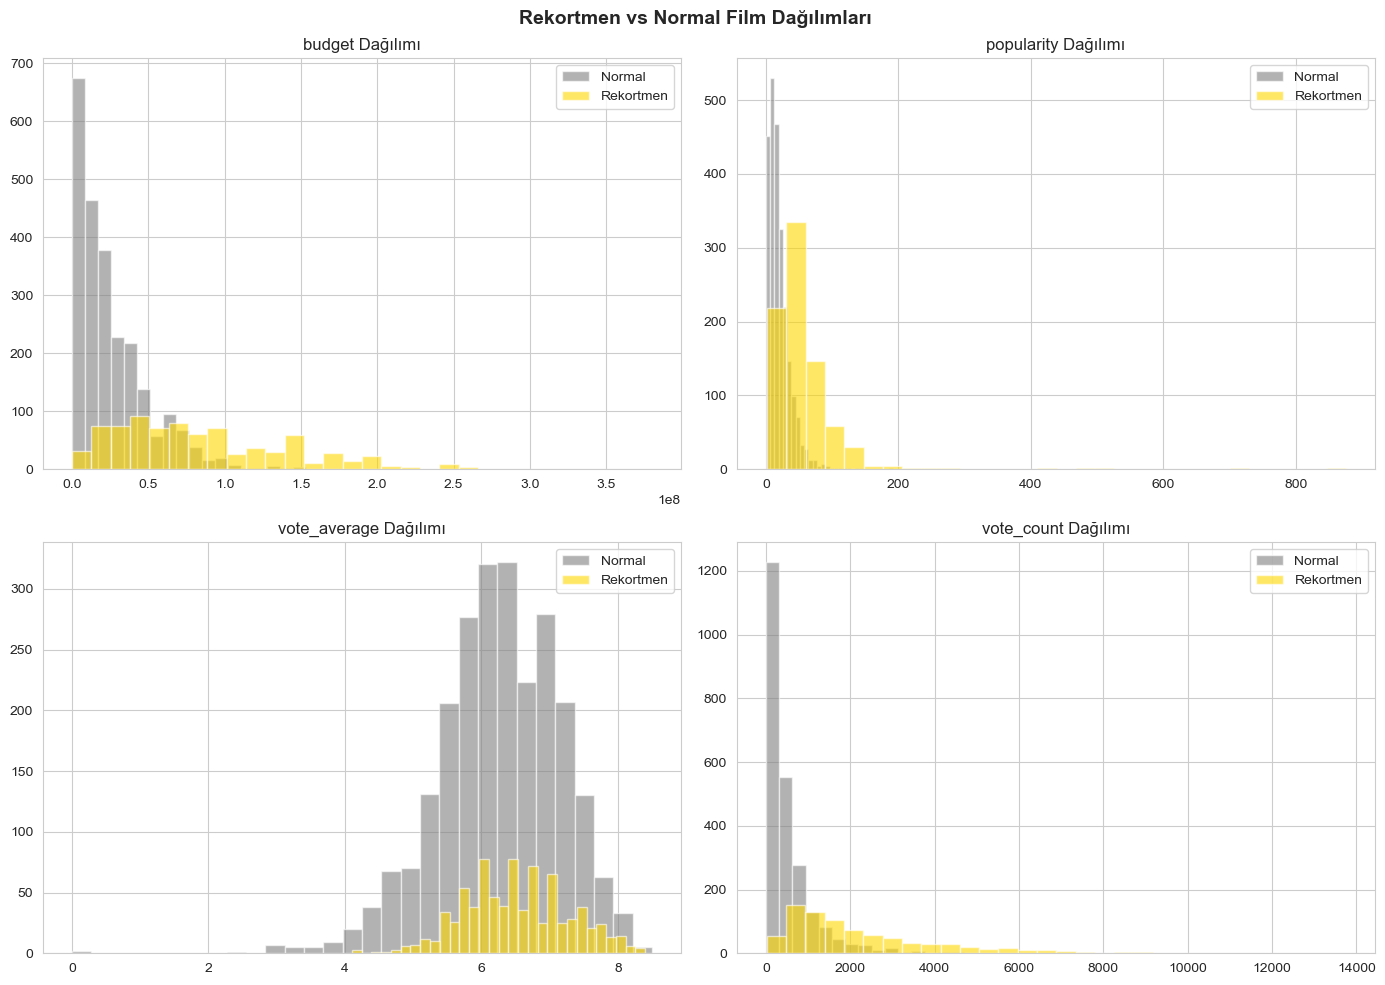


TÜR BAZLI KARŞILAŞTIRMA (Rekortmen vs Normal Filmlerdeki Oran)


,Rekortmen (%),Normal (%),Fark (%)
Adventure,38.4,14.5,23.9
Action,41.8,24.0,17.8
Family,20.6,8.2,12.4
Fantasy,19.5,7.6,11.9
Animation,13.0,3.4,9.6
Science Fiction,18.8,11.5,7.3
War,3.6,3.8,-0.2
Comedy,34.0,34.5,-0.5
Mystery,7.7,8.4,-0.7
Thriller,27.6,29.4,-1.8


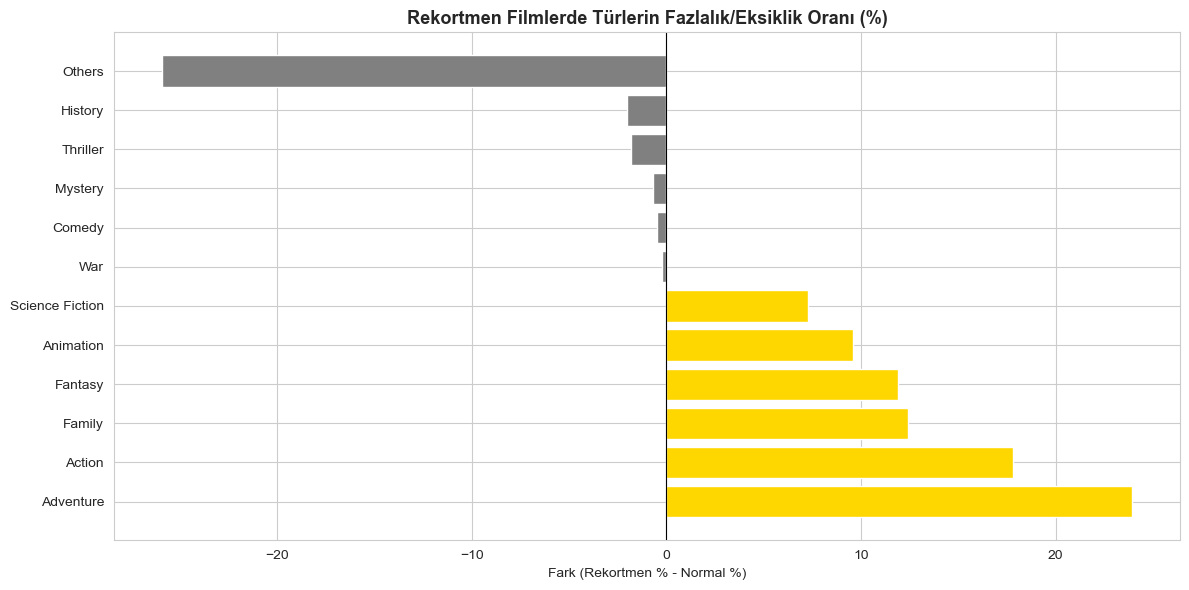

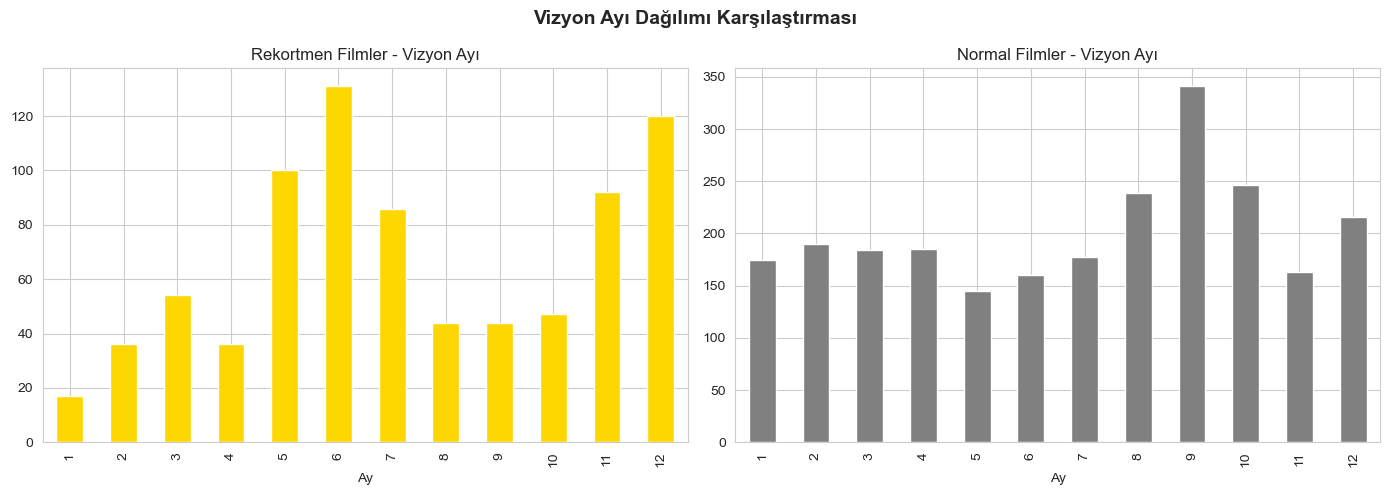


ÖZET BULGULAR
Rekortmen film sayısı: 807 (25.0%)
Normal film sayısı:    2421 (75.0%)

Rekortmen filmlerin ortalama bütçesi: $85,970,433
Normal filmlerin ortalama bütçesi:     $25,565,082

Rekortmen filmlerin ortalama popülaritesi: 56.7
Normal filmlerin ortalama popülaritesi:     19.8

Rekortmen filmlerde en baskın tür: Adventure (+23.9%)


In [102]:
# --- Gişe Rekortmeni vs Normal Film Karşılaştırması ---
blockbuster = regulated_df[regulated_df['is_blockbuster'] == 1]
non_blockbuster = regulated_df[regulated_df['is_blockbuster'] == 0]

# 1. Sayısal özelliklerin karşılaştırması
compare_cols = ['budget', 'popularity', 'vote_average', 'vote_count']
comparison = pd.DataFrame({
    'Rekortmen (Ortalama)': blockbuster[compare_cols].mean(),
    'Normal (Ortalama)': non_blockbuster[compare_cols].mean(),
    'Rekortmen (Medyan)': blockbuster[compare_cols].median(),
    'Normal (Medyan)': non_blockbuster[compare_cols].median()
})
print('='*70)
print('GİŞE REKORTMEN vs NORMAL FİLM - SAYISAL ÖZELLİK KARŞILAŞTIRMASI')
print('='*70)
display(comparison)

# 2. Görselleştirme: Sayısal özellik dağılımları
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, col in enumerate(compare_cols):
    row, c = divmod(idx, 2)
    axes[row][c].hist(non_blockbuster[col], bins=30, alpha=0.6, label='Normal', color='gray')
    axes[row][c].hist(blockbuster[col], bins=30, alpha=0.6, label='Rekortmen', color='gold')
    axes[row][c].set_title(f'{col} Dağılımı')
    axes[row][c].legend()
plt.suptitle('Rekortmen vs Normal Film Dağılımları', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Tür bazlı karşılaştırma
genre_cols = list(mlb.classes_)
genre_comparison = pd.DataFrame({
    'Rekortmen (%)': (blockbuster[genre_cols].mean() * 100).round(1),
    'Normal (%)': (non_blockbuster[genre_cols].mean() * 100).round(1)
})
genre_comparison['Fark (%)'] = (genre_comparison['Rekortmen (%)'] - genre_comparison['Normal (%)']).round(1)
genre_comparison = genre_comparison.sort_values('Fark (%)', ascending=False)

print('\n' + '='*70)
print('TÜR BAZLI KARŞILAŞTIRMA (Rekortmen vs Normal Filmlerdeki Oran)')
print('='*70)
display(genre_comparison)

# 4. Tür farkı grafiği
plt.figure(figsize=(12, 6))
colors = ['gold' if x > 0 else 'gray' for x in genre_comparison['Fark (%)']]
plt.barh(genre_comparison.index, genre_comparison['Fark (%)'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Rekortmen Filmlerde Türlerin Fazlalık/Eksiklik Oranı (%)', fontsize=13, fontweight='bold')
plt.xlabel('Fark (Rekortmen % - Normal %)')
plt.tight_layout()
plt.show()

# 5. Vizyon ayı karşılaştırması
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
blockbuster['release_month'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='gold')
axes[0].set_title('Rekortmen Filmler - Vizyon Ayı')
axes[0].set_xlabel('Ay')
non_blockbuster['release_month'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='gray')
axes[1].set_title('Normal Filmler - Vizyon Ayı')
axes[1].set_xlabel('Ay')
plt.suptitle('Vizyon Ayı Dağılımı Karşılaştırması', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n' + '='*70)
print('ÖZET BULGULAR')
print('='*70)
print(f"Rekortmen film sayısı: {len(blockbuster)} ({len(blockbuster)/len(regulated_df)*100:.1f}%)")
print(f"Normal film sayısı:    {len(non_blockbuster)} ({len(non_blockbuster)/len(regulated_df)*100:.1f}%)")
print(f"\nRekortmen filmlerin ortalama bütçesi: ${blockbuster['budget'].mean():,.0f}")
print(f"Normal filmlerin ortalama bütçesi:     ${non_blockbuster['budget'].mean():,.0f}")
print(f"\nRekortmen filmlerin ortalama popülaritesi: {blockbuster['popularity'].mean():.1f}")
print(f"Normal filmlerin ortalama popülaritesi:     {non_blockbuster['popularity'].mean():.1f}")
top_genre = genre_comparison['Fark (%)'].idxmax()
print(f"\nRekortmen filmlerde en baskın tür: {top_genre} (+{genre_comparison.loc[top_genre, 'Fark (%)']:.1f}%)")

## 5. Model Değerlendirme ve Görselleştirme

Bu bölümde en iyi modelin performansını ve özellik önemlerini inceliyoruz.

### 5.0. Model Karşılaştırma Tablosu

Eğitilen tüm modellerin test seti üzerindeki performans metriklerini karşılaştırıyoruz.

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.888545,0.808219,0.728395,0.766234
1,CatBoost,0.891641,0.802632,0.753086,0.777070
2,LightGBM,0.888545,0.752809,0.827160,0.788235


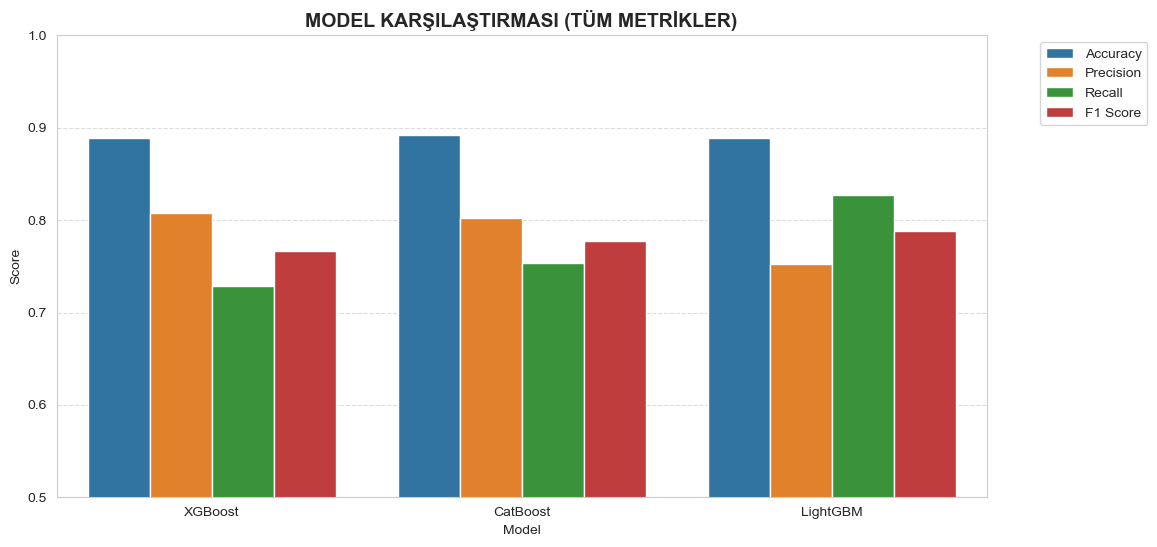

In [103]:
results = {
    'Model': ['XGBoost', 'CatBoost', 'LightGBM'],
    'Accuracy': [
        accuracy_score(y_test, best_model.predict(X_test)), 
        accuracy_score(y_test, best_cat.predict(X_test)), 
        accuracy_score(y_test, best_light.predict(X_test))
    ],
    'Precision': [
        precision_score(y_test, best_model.predict(X_test)), 
        precision_score(y_test, best_cat.predict(X_test)), 
        precision_score(y_test, best_light.predict(X_test))
    ],
    'Recall': [
        recall_score(y_test, best_model.predict(X_test)), 
        recall_score(y_test, best_cat.predict(X_test)), 
        recall_score(y_test, best_light.predict(X_test))
    ],
    'F1 Score': [
        f1_score(y_test, best_model.predict(X_test)), 
        f1_score(y_test, best_cat.predict(X_test)), 
        f1_score(y_test, best_light.predict(X_test))
    ]
}

results_df = pd.DataFrame(results)
display(results_df)

# Görselleştirme için veriyi uzun formata getiriyoruz
df_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted)
plt.title('MODEL KARŞILAŞTIRMASI (TÜM METRİKLER)', fontsize=14, fontweight='bold')
plt.ylim(0.5, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

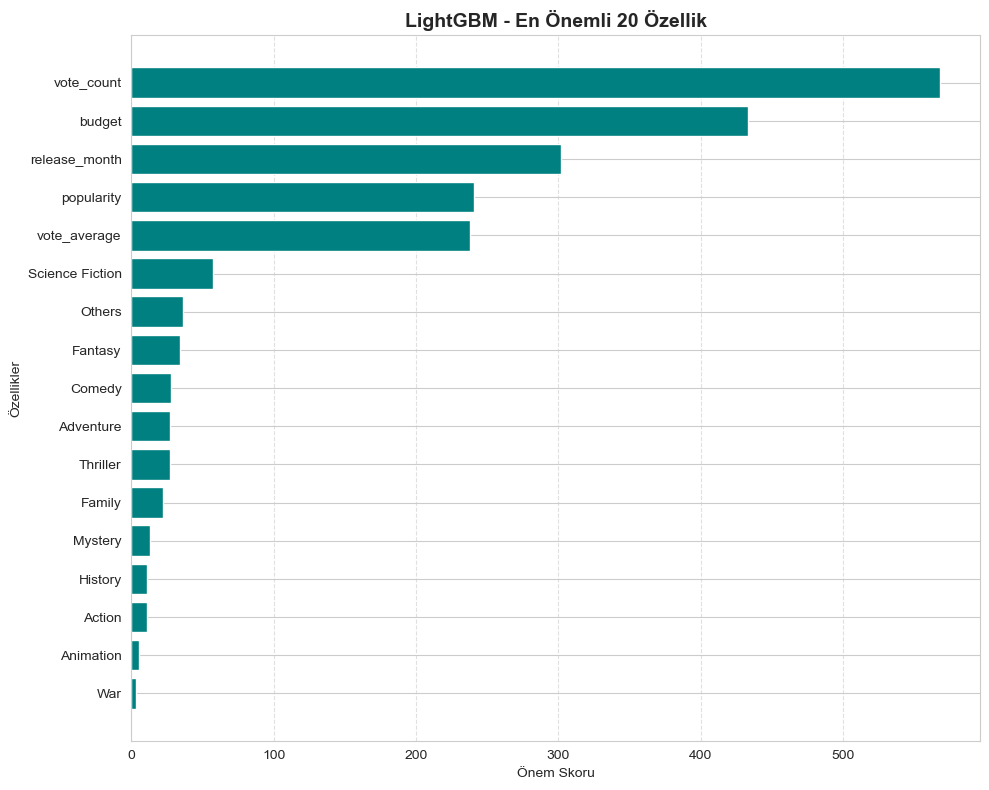

In [104]:
# Özellik Önemi (Feature Importance) Grafiği ve Değerlerin Yazdırılması
def plot_feature_importance(importance, names, model_type, top_n=20):
    fi_df = pd.DataFrame({
        'feature': names,
        'importance': importance
    }).sort_values('importance', ascending=False) # En yüksekten en düşüğe

    # Grafik oluştur
    plot_df = fi_df.head(top_n).sort_values('importance', ascending=True)
    plt.figure(figsize=(10, 8))
    plt.barh(plot_df['feature'], plot_df['importance'], color='teal')
    plt.title(f'{model_type} - En Önemli {top_n} Özellik', fontsize=14, fontweight='bold')
    plt.xlabel('Önem Skoru')
    plt.ylabel('Özellikler')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_feature_importance(best_light.feature_importances_, features, 'LightGBM')

### 5.1. Karmaşıklık Matrisi ve ROC Eğrisi

Modelin tahmin performansını daha detaylı incelemek için karmaşıklık matrisi ve ROC eğrisini kullanıyoruz.

<Figure size 800x600 with 0 Axes>

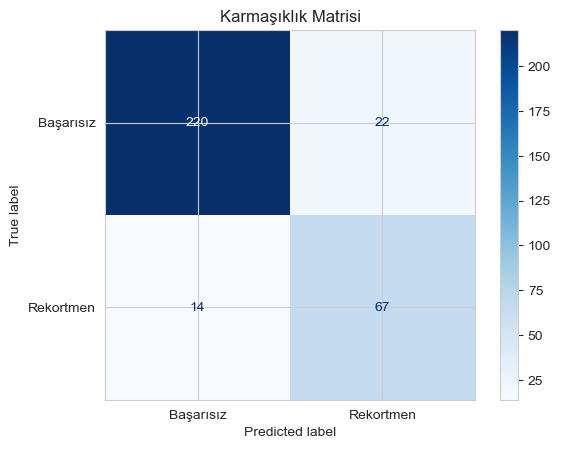

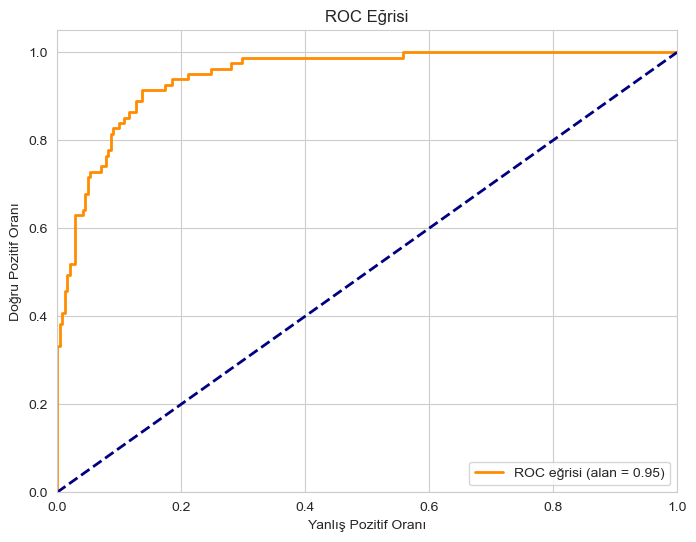

In [105]:


# Karmaşıklık Matrisi (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Başarısız', 'Rekortmen'])
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title('Karmaşıklık Matrisi')
plt.show()

# ROC Eğrisi
y_score = best_light.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC eğrisi (alan = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı')
plt.ylabel('Doğru Pozitif Oranı')
plt.title('ROC Eğrisi')
plt.legend(loc="lower right")
plt.show()

## 6. Sonuç

Bu çalışmada, film özelliklerini kullanarak hasılat tahmini yapan modeller geliştirilmiştir. En iyi sonuçlar Gradient Boosting modelleri (özellikle LightGBM ve XGBoost) ile elde edilmiştir. Özellik önemi analizi, bütçe ve popülaritenin hasılat üzerindeki en belirleyici faktörler olduğunu göstermektedir.